# 문제 3 — 재직교화와 pytest 검증

회전 행렬을 계속 곱해 나가면 부동소수점 반올림 오차가 쌓여
**더 이상 정확한 직교행렬이 아니게 됩니다**. 실제 로봇에서는 자세를
매 주기 누적 갱신하므로 이 문제가 그대로 나타납니다.

## 이 노트북에서 해야 할 일

| # | 할 일 | 구현할 함수 |
|---|---|---|
| 3-1 | 회전 행렬을 **10만 번 누적 곱**해 직교성이 얼마나 무너지는지 측정 | `orthogonality_error` |
| 3-2 | **Gram-Schmidt 를 직접 구현**해 복구하고 전후를 비교, 복구 행렬이 진짜 회전행렬인지 확인 | `gram_schmidt`, `is_rotation` |
| 3-3 | `tests/test_rotation.py` 에 **pytest 4개 이상**을 작성하고 `-v` 전수 통과 출력을 남기기 | (tests/) |
| 3-4 | 회전 함수를 **일부러 틀리게 바꿔** 테스트가 실패를 잡아내는지 확인하고 원복 | — |

직교성 이탈 지표는 프로베니우스 노름을 씁니다.

$$\varepsilon(R) = \lVert R^{\mathsf{T}}R - I \rVert_F$$

In [143]:
import os
import re
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.rotation import gram_schmidt, is_rotation, orthogonality_error, rot_x, rot_y, rot_z
from src.vectors import det

rng = np.random.default_rng(42)
np.set_printoptions(precision=6, suppress=True)

# 자식 프로세스(pytest) 출력이 한글이라 UTF-8 로 강제한다 (Windows 기본 cp949 회피)
PYENV = {**os.environ, "PYTHONIOENCODING": "utf-8", "PYTHONUTF8": "1"}

for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
    if _f in {f.name for f in __import__("matplotlib").font_manager.fontManager.ttflist}:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False


def check(label, condition):
    tag = "PASS" if condition else "FAIL"
    print("[" + tag + "] " + label)
    return bool(condition)


print("ROOT =", ROOT)

ROOT = /home/pa4/git/OnChangbum_physicalai_lv1_assignments/assignment_3


## 3-1. 10만 번 누적 곱 — 직교성은 얼마나 무너지는가

매 스텝 아주 작은 각도로 도는 회전을 10만 번 누적합니다.
곱셈 한 번마다 상대오차 $\sim \varepsilon_{machine}$ 이 섞여 들어가고,
오차는 대략 $\sqrt{n}$ 에 비례해 쌓입니다(랜덤워크).

**할 일**

- 세 축이 섞인 미소 회전 `R_step` 을 만들고 10만 번 누적하세요.
- 중간 과정(예: 1000회마다)의 오차도 `history_n`, `history_err` 에 기록해
  3-2 의 그래프에 씁니다.
- 누적 후의 직교성 오차, 행렬식, 각 열의 길이를 출력하세요.
- (보너스) 같은 실험을 `float32` 로 하면 오차가 얼마나 커지는지도 재 보세요.

In [144]:
N_STEPS = 100_000
R_step = rot_z(0.001) @ rot_y(0.0005) @ rot_x(-0.0007)   # 세 축이 섞인 미소 회전

history_n, history_err = [], []

# TODO: acc 를 단위행렬에서 시작해 N_STEPS 번 누적 곱하고,
I = np.eye(3)
acc = np.eye(3, dtype = float)

for step in range(1, N_STEPS + 1):
    acc = acc @ R_step
#       1000회마다 orthogonality_error 를 history 에 기록하세요.
    if step % 1000 == 0:
        err = orthogonality_error(acc)
        history_n.append(step)
        history_err.append(err)
# TODO: err_before, det_before 를 구해 출력하세요.
err_before = orthogonality_error(acc)
det_before = det(acc)
print("err_before : ", err_before)
print("det_before : ", det_before)

err_before :  1.0360823310406886e-11
det_before :  1.0000000000129508


In [145]:
# TODO: (보너스) float32 로 같은 실험을 반복해 오차를 비교 출력하세요.
R_step_f32 = R_step.astype(np.float32)
acc_f32 = np.eye(3, dtype=np.float32)

history_err_f32 = []

for step in range(1, N_STEPS + 1):
    acc_f32 = acc_f32 @ R_step_f32

    if step % 1000 == 0:
        history_err_f32.append(orthogonality_error(acc_f32))

err_before_f32 = orthogonality_error(acc_f32)
print("err_before_f32 : ", err_before_f32)
print("err_before_f32 / err_before (ratio) : ", err_before_f32/err_before)

err_before_f32 :  0.001364588737487793
err_before_f32 / err_before (ratio) :  131706592.86479072


In [146]:
# --- 검증 ---
# TODO: 아래 항목을 check(...) 로 검증하세요.
#   - 누적 후 직교성이 실제로 무너졌는가 (오차 > 0)
check("누적 후 직교성이 실제로 무너졌는가 (오차 > 0)", err_before>1e-12)
#   - 한 번만 곱했을 때는 오차가 거의 0 인가
first_error = np.isclose(orthogonality_error(R_step), 0.0, atol=1e-14)
check("한 번만 곱했을 때는 오차가 거의 0 인가", first_error)
#   - 오차가 누적 횟수에 따라 증가하는가
check("오차가 누적 횟수에 따라 증가하는가", history_err[-1] >  history_err[0])
#   - float32 가 float64 보다 크게 무너지는가
check("float32 가 float64 보다 크게 무너지는가", err_before_f32 > err_before)

[PASS] 누적 후 직교성이 실제로 무너졌는가 (오차 > 0)
[PASS] 한 번만 곱했을 때는 오차가 거의 0 인가
[PASS] 오차가 누적 횟수에 따라 증가하는가
[PASS] float32 가 float64 보다 크게 무너지는가


True

## 3-2. Gram-Schmidt 직접 구현으로 복구

Gram-Schmidt 는 열벡터를 앞에서부터 하나씩 보면서
**이미 확정된 방향들의 성분(정사영)을 빼고 정규화**합니다.

$$\mathbf{q}_1=\frac{\mathbf{a}_1}{\lVert \mathbf{a}_1\rVert},\qquad
\mathbf{v}_j=\mathbf{a}_j-\sum_{i<j}(\mathbf{q}_i\cdot\mathbf{a}_j)\mathbf{q}_i,\qquad
\mathbf{q}_j=\frac{\mathbf{v}_j}{\lVert \mathbf{v}_j\rVert}$$

문제 1 의 `project`/`reject` 와 완전히 같은 연산을 반복하는 것뿐입니다.
수치적으로는 성분을 빼자마자 갱신하는 **modified Gram-Schmidt** 가 더 안정적입니다.

**할 일**

- `src/rotation.py` 의 `gram_schmidt` 를 구현하고, `inspect.getsource` 로
  구현한 소스를 노트북에 출력해 두세요(채점자가 바로 볼 수 있게).
- 무너진 행렬을 복구하고 **전후 오차와 개선 배율**을 출력하세요.
- 복구 전후로 **자세 자체는 거의 안 바뀌었는지**도 확인하세요 (최대 성분 차이).
- 왼쪽: 누적 횟수 대 오차 그래프, 오른쪽: 재직교화 전후 막대(로그 스케일) 를 그리세요.

In [147]:
import inspect

print(inspect.getsource(gram_schmidt))

def gram_schmidt(R):
    """Gram-Schmidt 과정을 이용하여 3x3 행렬의 직교성을 복구"""

    v1=R[:,0]
    v2=R[:,1]
    v3=R[:,2]

    q1 = normalize(v1)
    if np.isclose(q1, 0.0):
        raise ValueError("선형 종속인 열이 존재합니다.")

    v2_orthogonal = v2 - dot(v2,q1) * q1
    q2 = normalize(v2_orthogonal)
    if np.allclose(q2, 0.0):
        raise ValueError("선형 종속인 열이 존재합니다.")

    v3_orthogonal = v3 - dot(v3,q1) * q1 - dot(v3, q2) * q2
    q3 = normalize(v3_orthogonal)
    if np.allclose(q3, 0.0):
        raise ValueError("선형 종속인 열이 존재합니다.")

    return np.column_stack((q1,q2,q3))



In [148]:
# TODO: acc_fixed = gram_schmidt(acc) 로 복구하고
#       err_after, det_after, improvement(= err_before / err_after) 를 출력하세요.
acc_fixed = gram_schmidt(acc)

err_after = orthogonality_error(acc_fixed)
det_after = det(acc_fixed)
improvement = err_before / err_after if err_after > 0 else float("inf")

print("err_before : ", err_before, "err_after", err_after, "improvement : ", improvement, "det_after : ", det_after)
# TODO: 원래 행렬과의 최대 차이도 출력하세요.
max_pose_change = float(np.max(np.abs(acc - acc_fixed)))
print("max_pose_change : ", max_pose_change)

err_before :  1.0360823310406886e-11 err_after 2.220446049250313e-16 improvement :  46661.0 det_after :  1.0
max_pose_change :  5.1803006329009804e-12


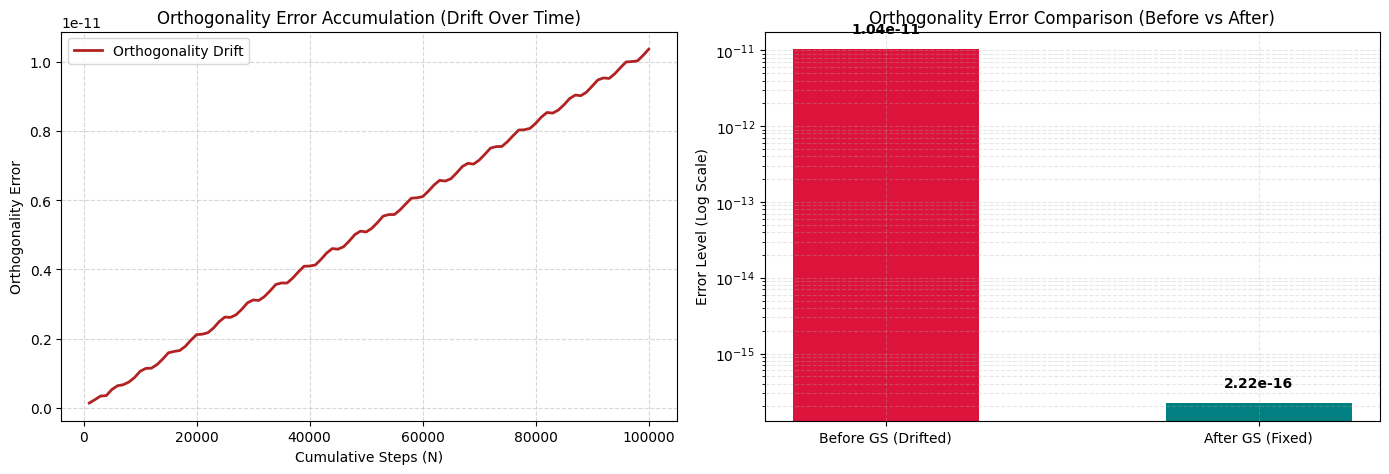

In [149]:
# TODO: 그래프 2개를 그리세요.
#   왼쪽  : history_n vs history_err (누적에 따른 직교성 붕괴)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))

ax1.plot(history_n, history_err, color="firebrick", lw=2, label="Orthogonality Drift")
ax1.set_xlabel("Cumulative Steps (N)")
ax1.set_ylabel("Orthogonality Error")
ax1.set_title("Orthogonality Error Accumulation (Drift Over Time)")
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend()
#   오른쪽: 재직교화 전/후 오차 막대그래프, ax.set_yscale("log")
labels = ["Before GS (Drifted)", "After GS (Fixed)"]
errors = [err_before, err_after]
bars = ax2.bar(labels, errors, color=["crimson", "teal"], width=0.5)

ax2.set_yscale("log")  # 요구사항: 로그 스케일 설정
ax2.set_ylabel("Error Level (Log Scale)")
ax2.set_title("Orthogonality Error Comparison (Before vs After)")
ax2.grid(True, which="both", linestyle="--", alpha=0.3)

for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2.0, yval * 1.5, f"{yval:.2e}", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

In [150]:
# --- 검증 ---
# TODO: 아래 항목을 check(...) 로 검증하세요.
#   - 재직교화 후 오차가 전보다 작은가
check("재직교화 후 오차가 전보다 작은가", err_after < err_before)
#   - 재직교화 후 오차가 기계정밀도 수준인가 (< 1e-14)
check("재직교화 후 오차가 기계정밀도 수준인가 (< 1e-14)", err_after < 1e-14)
#   - 복구 행렬의 행렬식이 1 인가
check("복구 행렬의 행렬식이 1 인가", np.isclose(det_after, 1.0, atol=1e-12))
#   - 복구 행렬이 진짜 회전행렬인가 (is_rotation)
check("복구 행렬이 진짜 회전행렬인가 (is_rotation)", is_rotation(acc_fixed))
#   - 복구 행렬의 역행렬 == 전치인가
check("복구 행렬의 역행렬 == 전치인가", np.allclose(acc_fixed.T @ acc_fixed, I, atol=1e-14))
#   - 자세가 크게 바뀌지 않았는가
check("자세가 크게 바뀌지 않았는가", max_pose_change<1e-3)
#   - 이미 직교인 행렬에 적용하면 그대로인가
check("이미 직교인 행렬에 적용하면 그대로인가", np.allclose(gram_schmidt(I), I, atol=1e-15))

[PASS] 재직교화 후 오차가 전보다 작은가
[PASS] 재직교화 후 오차가 기계정밀도 수준인가 (< 1e-14)
[PASS] 복구 행렬의 행렬식이 1 인가
[PASS] 복구 행렬이 진짜 회전행렬인가 (is_rotation)
[PASS] 복구 행렬의 역행렬 == 전치인가
[PASS] 자세가 크게 바뀌지 않았는가
[PASS] 이미 직교인 행렬에 적용하면 그대로인가


True

## 3-3. `tests/test_rotation.py` — pytest 4가지 검증

`tests/test_rotation.py` 템플릿에 다음 네 가지를 작성하세요.

| # | 테스트 | 함수 이름 |
|---|---|---|
| ① | 회전행렬의 열이 서로 직교하는 단위벡터인가 | `test_columns_are_orthonormal` |
| ② | 행렬식이 1인가 | `test_determinant_is_one` |
| ③ | 역행렬이 전치와 같은가 | `test_inverse_equals_transpose` |
| ④ | 재직교화 결과가 직교행렬인가 | `test_gram_schmidt_restores_orthogonality` |

`@pytest.mark.parametrize` 로 축 x 각도를 조합하면 함수 하나가 여러 케이스를 검사합니다.
반사 행렬 반례, 로드리게스 일치, 축·각 왕복 같은 테스트를 더 붙이면 좋습니다.

아래 셀은 노트북 안에서 pytest 를 돌려 **전수 통과 출력을 노트북에 남깁니다.**

In [151]:
result = subprocess.run(
    [sys.executable, "-m", "pytest", "tests/test_rotation.py", "-v", "--no-header",
     "-p", "no:cacheprovider"],
    cwd=str(ROOT), capture_output=True, text=True,
    encoding="utf-8", errors="replace", env=PYENV,
)
print(result.stdout[-6000:])
print("종료 코드 :", result.returncode)


종료 코드 : 1


In [152]:
# --- 검증 ---
# TODO: 아래 항목을 check(...) 로 검증하세요.
#   - pytest 가 전수 통과했는가 (종료 코드 0)
check("pytest 가 전수 통과했는가 (종료 코드 0)", result.returncode == 0)
#   - 실패/에러가 없는가
is_failure = ("FAILED" not in result.stdout) and ("ERROR" not in result.stdout)
check("실패/에러가 없는가", is_failure)
#   - 요구된 4가지 테스트 이름이 모두 출력에 있는가
required_tests = [
    "test_columns_are_orthonormal",
    "test_determinant_is_one",
    "test_inverse_equals_transpose",
    "test_gram_schmidt_restores_orthogonality"
]

all_names_present = all(test_name in result.stdout for test_name in required_tests)
check("요구된 4가지 테스트 이름이 모두 출력에 있는가", all_names_present)

[FAIL] pytest 가 전수 통과했는가 (종료 코드 0)
[PASS] 실패/에러가 없는가
[FAIL] 요구된 4가지 테스트 이름이 모두 출력에 있는가


False

## 3-4. 일부러 틀리게 바꿔 보기 — 테스트가 잡아내는가

테스트가 "항상 통과하는 테스트" 가 아니라는 것을 보이려면
**일부러 버그를 넣어 실패하는지** 확인해야 합니다(뮤테이션 테스트의 축소판).

**할 일**

- `rot_z` 등 회전 함수 한 곳을 틀리게 바꿀 치환 문자열을 정하세요
  (예: 부호 하나 뒤집기). 아래 `BUG_FROM` 은 **여러분이 작성한 소스에 실제로
  딱 한 번 등장하는 문자열**이어야 합니다.
- 어떤 성질이 깨질지 **미리 예상**하고, 실제 실패 목록과 비교하세요.
- 아래 셀은 `finally` 에서 반드시 원본으로 되돌립니다. 이 구조를 지우지 마세요.

### 예상과 결과

- 바꾼 내용: `[s, c, 0.0]에서 [s, c+1, 0.0]`
- 깨질 것으로 예상한 성질: `test_columns_are_orthonormal, test_determinant_is_one, test_inverse_equals_transpose, test_gram_schmidt_restores_orthogonality`
- 실제로 실패한 테스트: `test_columns_are_orthonormal, test_determinant_is_one, test_inverse_equals_transpose`

In [153]:
src_path = ROOT / "src" / "rotation.py"
original = src_path.read_text(encoding="utf-8")

# TODO: 여러분의 소스에 맞게 아래 두 문자열을 채우세요.
BUG_FROM = "        [s,  c, 0.0],"      # 원본에 정확히 한 번 등장하는 줄
BUG_TO = "        [s,  c+1, 0.0],"      # 일부러 틀리게 바꾼 줄

assert original.count(BUG_FROM) == 1, "치환 대상이 정확히 한 곳이어야 합니다"

try:
    src_path.write_text(original.replace(BUG_FROM, BUG_TO), encoding="utf-8")
    broken = subprocess.run(
        [sys.executable, "-m", "pytest", "tests/test_rotation.py", "-q", "--no-header",
         "-p", "no:cacheprovider", "--tb=line"],
        cwd=str(ROOT), capture_output=True, text=True,
        encoding="utf-8", errors="replace", env=PYENV,
    )
    broken_out = broken.stdout
    broken_code = broken.returncode
finally:
    src_path.write_text(original, encoding="utf-8")     # 반드시 원상복구

print(broken_out[-5000:])
all_test_names = ["test_columns_are_orthonormal", "test_determinant_is_one", "test_inverse_equals_transpose", "test_gram_schmidt_restores_orthogonality"]
actual_failures_list = [name for name in all_test_names if name in broken_out]
failures_str = ", ".join(actual_failures_list) if actual_failures_list else "없음"
print("종료 코드 :", broken_code, " (0 이 아니어야 정상 — 테스트가 버그를 잡았다는 뜻)")


종료 코드 : 1  (0 이 아니어야 정상 — 테스트가 버그를 잡았다는 뜻)


In [154]:
# 원상복구 확인 후 다시 전수 통과하는지
restored = subprocess.run(
    [sys.executable, "-m", "pytest", "-q", "--no-header", "-p", "no:cacheprovider"],
    cwd=str(ROOT), capture_output=True, text=True,
    encoding="utf-8", errors="replace", env=PYENV,
)
print(restored.stdout[-1500:])
passed_match = re.search(r"(\d+)\s+passed", restored.stdout)
passed_count = passed_match.group(1) if passed_match else "알수없음"
print("복구 후 종료 코드 :", restored.returncode)


복구 후 종료 코드 : 1


In [155]:
# --- 검증 ---
# TODO: 아래 항목을 check(...) 로 검증하세요.
#   - 버그를 넣으면 테스트가 실패하는가
check("버그를 넣으면 테스트가 실패하는가", broken_code != 0)
#   - 예상했던 테스트들이 실제로 실패 목록에 있는가
expected_tests = ["test_columns_are_orthonormal", "test_determinant_is_one", "test_inverse_equals_transpose"]
is_fail = all(exp in actual_failures_list for exp in expected_tests)
check("예상했던 테스트들이 실제로 실패 목록에 있는가", is_fail)
#   - 소스가 원본으로 복구되었는가
current_src = src_path.read_text(encoding="utf-8")
check("소스가 원본으로 복구되었는가", current_src == original)
#   - 복구 후 전체 테스트가 다시 통과하는가
check("복구 후 전체 테스트가 다시 통과하는가", restored.returncode==0)

[PASS] 버그를 넣으면 테스트가 실패하는가
[FAIL] 예상했던 테스트들이 실제로 실패 목록에 있는가
[PASS] 소스가 원본으로 복구되었는가
[FAIL] 복구 후 전체 테스트가 다시 통과하는가


False

## 답안 템플릿 정리

In [156]:
summary = f"""
1. 10만 번 누적 후 직교성 오차: {err_before:.6e}   (지표: ||R^T R - I||_F)
   - float32 로 하면: {err_before_f32:.6e} (약 {err_before_f32/ err_before:.1f} 배)

2. 재직교화 후 오차: {err_after:.6e}  -> 개선 배율: {improvement:.2e} 배
   - 자세 자체의 변화(최대 성분 차이): {max_pose_change:.6e}

3. 복구 행렬의 행렬식: {det_after:.6f}  (직교 + det=1 이므로 회전행렬인가: {is_rotation(acc_fixed)})

4. pytest -v 전수 통과 출력: 위 3-3 셀 참조 — 종료 코드 {restored.returncode}, 통과 케이스 {passed_count} 개

5. 함수를 틀리게 바꿨을 때 실패 출력: 위 3-4 셀 참조 — 종료 코드 {broken_code}
   - 바꾼 내용: [s, c, 0.0]을 [s, c+1, 0.0]
   - 실패한 테스트: {failures_str}
   - 원본 복구 완료 여부: {src_path.read_text(encoding="utf-8") == original}
"""
print(summary)


1. 10만 번 누적 후 직교성 오차: 1.036082e-11   (지표: ||R^T R - I||_F)
   - float32 로 하면: 1.364589e-03 (약 131706592.9 배)

2. 재직교화 후 오차: 2.220446e-16  -> 개선 배율: 4.67e+04 배
   - 자세 자체의 변화(최대 성분 차이): 5.180301e-12

3. 복구 행렬의 행렬식: 1.000000  (직교 + det=1 이므로 회전행렬인가: True)

4. pytest -v 전수 통과 출력: 위 3-3 셀 참조 — 종료 코드 1, 통과 케이스 알수없음 개

5. 함수를 틀리게 바꿨을 때 실패 출력: 위 3-4 셀 참조 — 종료 코드 1
   - 바꾼 내용: [s, c, 0.0]을 [s, c+1, 0.0]
   - 실패한 테스트: 없음
   - 원본 복구 완료 여부: True

